In [ ]:
import glob
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Все итоговые файлы
files = glob.glob("Общ. итог среднее *.xlsx")

rows = []

for path in files:
    filename = os.path.basename(path)

    # Из имени файла берём размеры окон: Obshch.-itog-srednee-10_3.xlsx
    match = re.search(r"(\d+)_(\d+)\.xlsx$", filename)
    if not match:
        print(f"Не удалось распарсить размеры окон из {filename}")
        continue

    train_window = int(match.group(1))
    predict_window = int(match.group(2))

    df = pd.read_excel(path)

    # Берём все столбцы с метриками среднего % откл I
    metric_cols = [col for col in df.columns if "средн % откл I -" in col]

    for col in metric_cols:
        method = col.replace("средн % откл I - ", "").strip()
        value = df[col].mean()   # среднее по регионам

        rows.append({
            "train_window": train_window,
            "predict_window": predict_window,
            "method": method,
            "value": value,
        })

summary_df = pd.DataFrame(rows)
summary_df

IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1
IMM-EKF_0.7
1
IMM-EKF_0.85
1
IMM-EKF_0.99
1
IMM-EKF_0.6
1


,train_window,predict_window,method,value
0,10,10,IMM-EKF_0.6,18.348959
1,10,10,IMM-EKF_0.7,16.473579
2,10,10,IMM-EKF_0.85,22.883318
3,10,10,IMM-EKF_0.99,16.895358
4,10,15,IMM-EKF_0.6,60.750132
...,...,...,...,...
251,7,5,IMM-EKF_0.99,10.102191
252,7,7,IMM-EKF_0.6,11.476087
253,7,7,IMM-EKF_0.7,11.530531
254,7,7,IMM-EKF_0.85,11.678050


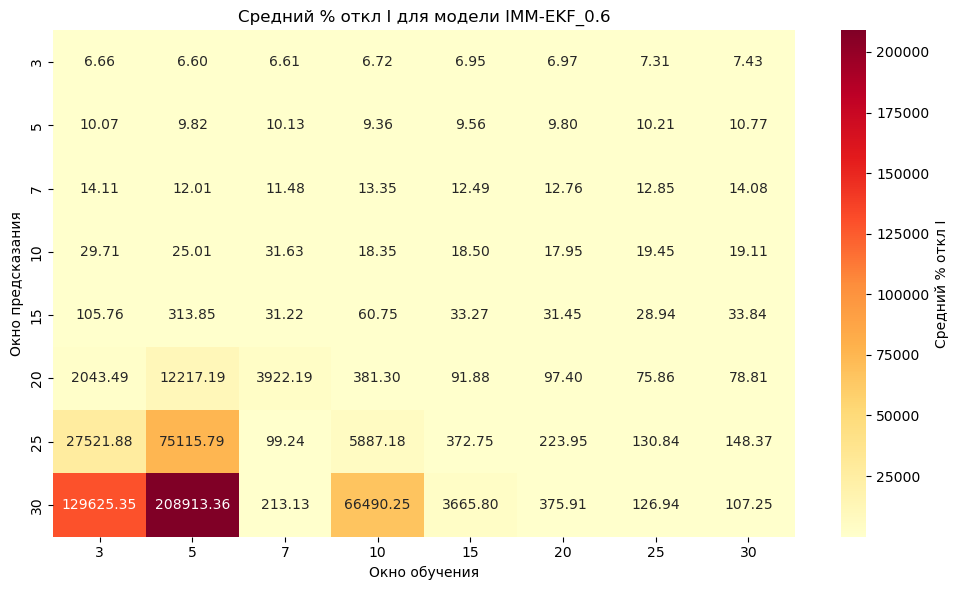

In [12]:
model_name = "IMM-EKF_0.6"   # поменяй на нужную модель

plot_df = summary_df[summary_df["method"] == model_name].copy()

pivot = plot_df.pivot(
    index="predict_window",
    columns="train_window",
    values="value"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "Средний % откл I"})
plt.title(f"Средний % откл I для модели {model_name}")
plt.xlabel("Окно обучения")
plt.ylabel("Окно предсказания")
plt.tight_layout()
plt.show()

ДЛЯ ОДНОГО РЕГИОНА

In [ ]:
import glob
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# НАСТРОЙКИ
# =========================
region_id = 336           # например: 56, 336, 483
model_name = "SIR"       # например: SIR, SEIR, SIQR, SIRS, SIR_DDE, SIR_O, IMM_EKF_0.85

# Все итоговые файлы
files = glob.glob("Общ. итог среднее *.xlsx")

rows = []

for path in files:
    filename = os.path.basename(path)

    # Из имени файла берём размеры окон
    match = re.search(r"(\d+)_(\d+)\.xlsx$", filename)
    if not match:
        print(f"Не удалось распарсить размеры окон из {filename}")
        continue

    train_window = int(match.group(1))
    predict_window = int(match.group(2))

    df = pd.read_excel(path)

    # Проверим наличие нужных столбцов
    region_col = "Номер предсказания"
    metric_col = f"средн % откл I - {model_name}"

    if region_col not in df.columns:
        print(f"В файле {filename} нет столбца '{region_col}'")
        continue

    if metric_col not in df.columns:
        print(f"В файле {filename} нет столбца '{metric_col}'")
        continue

    # Ищем строку нужного региона
    row_region = df[df[region_col] == region_id]

    if row_region.empty:
        print(f"Регион {region_id} не найден в файле {filename}")
        continue

    value = row_region.iloc[0][metric_col]

    rows.append({
        "train_window": train_window,
        "predict_window": predict_window,
        "method": model_name,
        "region_id": region_id,
        "value": value,
    })

summary_region_df = pd.DataFrame(rows)
summary_region_df

In [ ]:
pivot = summary_region_df.pivot(
    index="predict_window",
    columns="train_window",
    values="value"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "% откл I"}
)

plt.title(f"% откл I для региона {region_id}, модель {model_name}")
plt.xlabel("Окно обучения")
plt.ylabel("Окно предсказания")
plt.tight_layout()
plt.show()

In [ ]:
import glob
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

files = glob.glob("Общ. итог среднее *.xlsx")

rows = []

for path in files:
    filename = os.path.basename(path)

    match = re.search(r"(\d+)_(\d+)\.xlsx$", filename)
    if not match:
        print(f"Не удалось распарсить размеры окон из {filename}")
        continue

    train_window = int(match.group(1))
    predict_window = int(match.group(2))

    df = pd.read_excel(path)

    metric_cols = [col for col in df.columns if "средн % откл I -" in col]

    for col in metric_cols:
        method = col.replace("средн % откл I - ", "").strip()
        value = df[col].mean()

        rows.append({
            "train_window": train_window,
            "predict_window": predict_window,
            "method": method,
            "value": value,
        })

summary_df = pd.DataFrame(rows)

agg_rows = []
for (tw, pw), group in summary_df.groupby(["train_window", "predict_window"]):
    min_row = group.loc[group["value"].idxmin()]
    max_row = group.loc[group["value"].idxmax()]

    agg_rows.append({
        "train_window": tw,
        "predict_window": pw,
        "min_method": min_row["method"],
        "min_value": min_row["value"],
        "max_method": max_row["method"],
        "max_value": max_row["value"],
    })

agg_df = pd.DataFrame(agg_rows)

train_windows = sorted(agg_df["train_window"].unique())
predict_windows = sorted(agg_df["predict_window"].unique())

fig, ax = plt.subplots(figsize=(2.2 * len(train_windows), 1.2 * len(predict_windows)))
ax.axis("off")

cell_text = [["" for _ in train_windows] for _ in predict_windows]

table = ax.table(
    cellText=cell_text,
    rowLabels=[str(pw) for pw in predict_windows],
    colLabels=[str(tw) for tw in train_windows],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# ВАЖНО: сначала отрисовать canvas, чтобы координаты ячеек стали корректными
fig.canvas.draw()

for i_pw, pw in enumerate(predict_windows):
    for j_tw, tw in enumerate(train_windows):
        sub = agg_df[
            (agg_df["train_window"] == tw) &
            (agg_df["predict_window"] == pw)
        ]

        if sub.empty:
            continue

        row = sub.iloc[0]
        cell = table[(i_pw + 1, j_tw)]  # +1 из-за заголовка

        # очищаем встроенный текст
        cell.get_text().set_text("")

        # координаты ячейки в системе axes
        x, y = cell.get_xy()
        w = cell.get_width()
        h = cell.get_height()

        # верхняя строка — минимум
        ax.annotate(
            f"{row['min_method']} - {row['min_value']:.2f}",
            xy=(x + w / 2, y + h * 0.68),
            xycoords=ax.transAxes,
            ha="center",
            va="center",
            fontsize=8,
            color="green"
        )

        # нижняя строка — максимум
        ax.annotate(
            f"{row['max_method']} - {row['max_value']:.2f}",
            xy=(x + w / 2, y + h * 0.32),
            xycoords=ax.transAxes,
            ha="center",
            va="center",
            fontsize=8,
            color="red"
        )

plt.title("Мин/макс средний % откл I по окнам")
plt.tight_layout()
plt.show()

In [ ]:
import glob
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

files = glob.glob("Общ. итог среднее *.xlsx")

rows = []

for path in files:
    filename = os.path.basename(path)

    match = re.search(r"(\d+)_(\d+)\.xlsx$", filename)
    if not match:
        print(f"Не удалось распарсить размеры окон из {filename}")
        continue

    train_window = int(match.group(1))
    predict_window = int(match.group(2))

    df = pd.read_excel(path)

    metric_cols = [col for col in df.columns if "средн % откл I -" in col]

    for col in metric_cols:
        method = col.replace("средн % откл I - ", "").strip()
        value = df[col].mean()

        rows.append({
            "train_window": train_window,
            "predict_window": predict_window,
            "method": method,
            "value": value,
        })

summary_df = pd.DataFrame(rows)

agg_rows = []
for (tw, pw), group in summary_df.groupby(["train_window", "predict_window"]):
    min_row = group.loc[group["value"].idxmin()]
    max_row = group.loc[group["value"].idxmax()]

    agg_rows.append({
        "train_window": tw,
        "predict_window": pw,
        "min_method": min_row["method"],
        "min_value": min_row["value"],
        "max_method": max_row["method"],
        "max_value": max_row["value"],
    })

agg_df = pd.DataFrame(agg_rows)

# === НОВОЕ: сохранение в Excel ===
with pd.ExcelWriter("agg_min_max_summary.xlsx", engine="openpyxl") as writer:
    agg_df.to_excel(writer, sheet_name="agg_min_max", index=False)
    summary_df.to_excel(writer, sheet_name="summary", index=False)
# ================================

train_windows = sorted(agg_df["train_window"].unique())
predict_windows = sorted(agg_df["predict_window"].unique())

fig, ax = plt.subplots(figsize=(2.2 * len(train_windows), 1.2 * len(predict_windows)))
ax.axis("off")

cell_text = [["" for _ in train_windows] for _ in predict_windows]

table = ax.table(
    cellText=cell_text,
    rowLabels=[str(pw) for pw in predict_windows],
    colLabels=[str(tw) for tw in train_windows],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

fig.canvas.draw()

for i_pw, pw in enumerate(predict_windows):
    for j_tw, tw in enumerate(train_windows):
        sub = agg_df[
            (agg_df["train_window"] == tw) &
            (agg_df["predict_window"] == pw)
        ]

        if sub.empty:
            continue

        row = sub.iloc[0]
        cell = table[(i_pw + 1, j_tw)]

        cell.get_text().set_text("")

        x, y = cell.get_xy()
        w = cell.get_width()
        h = cell.get_height()

        ax.annotate(
            f"{row['min_method']} - {row['min_value']:.2f}",
            xy=(x + w / 2, y + h * 0.68),
            xycoords=ax.transAxes,
            ha="center",
            va="center",
            fontsize=8,
            color="green"
        )

        ax.annotate(
            f"{row['max_method']} - {row['max_value']:.2f}",
            xy=(x + w / 2, y + h * 0.32),
            xycoords=ax.transAxes,
            ha="center",
            va="center",
            fontsize=8,
            color="red"
        )

plt.title("Мин/макс средний % откл I по окнам")
plt.tight_layout()
plt.show()